### testing ground

In [1032]:
import numpy as np
import pandas as pd
import networkx as nx
import functions_regular as fnr
import functions_subtrees as fns
import matplotlib.pyplot as plt
import importlib
import numpy.lib.recfunctions as rfn
import cProfile as cp
import random as rnd
import math
importlib.reload(fnr)
importlib.reload(fns)

H = parseStringToGraph('[[1,2], [2,3], [3,4], [3,5], [4,2], [4,5], [5,0]]')
G = parseStringToGraph('[[1,2], [2,3], [3,4], [3,5], [4,2], [4,5], [5,0]]')

# G = nx.scale_free_graph(6, seed=3)
# G = nx.to_undirected(G)
# K = nx.Graph()
# K.add_edges_from(G.edges())

# H = nx.scale_free_graph(5, seed=3)
# H = nx.to_undirected(H)
# J = nx.Graph()
# J.add_edges_from(H.edges())

######################################################################

# T =  fns.randomTree(5, 5)
# S = fns.randomTree(15, 1)

# T = parseStringToGraph('[[0,1], [0,2], [3,0], [4,0], [2,4]]')
# S = parseStringToGraph('[[0,1], [0,2], [3,0], [4,0], [2,4]]')
# K = nx.Graph()
# K.add_edges_from(T.edges())
# aut = fnr.findSubgraphInstances(T, K, False)
# M = fnr.symmetryConditions(aut)

a = fnr.findSubgraphInstances(H, G, True)
b = fns.findSubgraphInstances(H, G, True)

print(a, b, a == b)
# print(b)

[array([(1, 1), (2, 2), (3, 3)],
      dtype=[('domainNode', '<i4'), ('rangeNode', '<i4')])]
1.0
1 1.0 True


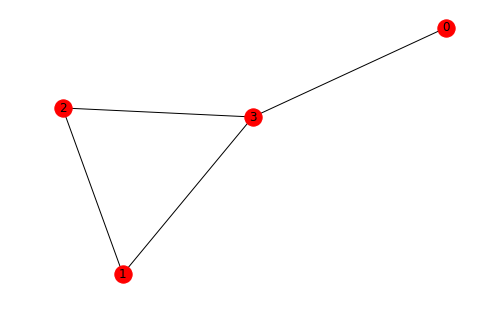

In [1026]:
# G = parseStringToGraph('[[0,1], [1,2], [2,0], [4,2], [3,4], [5,4], [6,4], [7,4]]')
H = fns.relabelByDegree(H)
nx.draw(H, with_labels=True)
# fns.onionDecompose(G)

In [940]:
G = parseStringToGraph('[[0,1], [1,2], [2,0], [4,2], [3,4], [5,4], [6,4], [7,4]]')



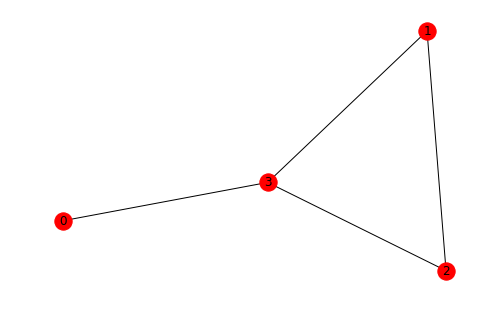

In [1027]:
# J = nx.Graph()
# J.add_edges_from(H.edges())
G = fns.relabelByDegree(G)
nx.draw(G, with_labels=True)

In [ ]:
nx.draw(T, with_labels=True)

In [ ]:
nx.draw(S, with_labels=True)
fns.compressTree(S, 14, 14)

In [536]:
fns.countRootedSubtrees(T, 4, S, 14)

12.0

In [539]:
f = fnr.Map([(2, 14)])
instances = fnr.isomorphicExtensions(f, T, S, 0, M)
len([tuple(i.getMap()) for i in instances])

10

In [ ]:
from matplotlib.pyplot import figure

G = nx.scale_free_graph(50, seed=21)
G = nx.to_undirected(G)

figure(num=None, figsize=(10, 10), dpi=80, facecolor='w', edgecolor='k')
plt.axis('off')
nx.draw_networkx(G, with_labels=True, node_size=0)


In [1033]:
file = 'test_data/tests.txt'

test_findSubgraphInstances(file, 'subtrees')

Test: triangle vs itself
H: [[0,1], [1,2], [0,2]] 
G: [[0,1], [1,2], [0,2]] 
correct number of instances: 1
instances found: 1
succeeded

Test: triangle in triangle-plus-line
H: [[0,1], [1,2], [0,2]]
G: [[1,2], [2,3], [1,3], [0,1]]
correct number of instances: 1
instances found: 1
succeeded

Test: triangle-plus-line in triangle:
H: [[1,2], [2,3], [1,3], [0,1]]
G: [[0,1], [1,2], [0,2]]
correct number of instances: 0
instances found: 0
succeeded

Test: triangle-plus-line vs itself
[array([(1, 1), (2, 2), (3, 3)],
      dtype=[('domainNode', '<i4'), ('rangeNode', '<i4')])]
1.0
H: [[0,1], [0,2], [1,2], [0,3]]
G: [[1,2], [2,3], [1,3], [0,1]]
correct number of instances: 1
instances found: 1.0
succeeded

Test: triangle in square-with-diagonal
H: [[0,1], [1,2], [0,2]]
G: [[0,1], [1,2], [2,3], [3,0], [0,2]]
correct number of instances: 2
instances found: 2
succeeded

Test: square vs square-with-diagonal
H: [[0,1], [1,2], [2, 3], [3,0]]
G: [[0,1], [1,2], [2,3], [3,0], [0,2]]
correct number of i

In [45]:
# input: edges of a graph written in bracketed pairs
# output: graph with corresponding edges
def parseStringToGraph(s):
    l = []
    
    if(s[len(s)-1] == ' '):
        s = s[:-1]
    
    if(s[0] == '[' and s[len(s)-1] == ']'):
        s = s[-(len(s)-1):-1]
        start = [key for key, val in enumerate(s) if val == '[']
        end = [key for key, val in enumerate(s) if val == ']']
        comma = [key for key, val in enumerate(s) if (val == ',' and not s[key-1] == ']')]
        
        for i in range(len(start)):
            left = [v for k, v in enumerate(s) if k in range(start[i]+1, comma[i])]
            right = [v for k, v in enumerate(s) if k in range(comma[i]+1, end[i])]
            
            left = int(''.join(left))
            right = int(''.join(right))
            l.append((left, right))
    
    H = nx.Graph()
    H.add_edges_from(l)
    
    return H


# reads the text file output by Josh and returns test name, hstring,
# gstring and answer in a dict
def parseFileToDict(file):
    f = open(file, 'r')
    D = {}
    index = 0
    first = True
    
    for line in f:
        if (line[0:4] == 'Test'):
            title = line[:-1]
            
        if (line[0] == '['):
            if (first):
                hstring = line[:-1]
                first = False
            else:
                gstring = line[:-1]
                first = True
            
            
        if (ord(line[0]) >= 48 and ord(line[0]) <= 57):
            ans = int(line)
            D[index] = {'title': title,
                        'hstring': hstring,
                        'gstring': gstring,
                        'answer': ans}
            index = index + 1
    
    return D


def test_findSubgraphInstances(file, which='regular'):
    
    D = parseFileToDict(file)
    
    for key in D.keys():
        print(D[key]['title'])
        H = nx.Graph()
        G = nx.Graph()
        
        hGraph = parseStringToGraph(D[key]['hstring'])
        gGraph = parseStringToGraph(D[key]['gstring'])
        
        H.add_edges_from(hGraph.edges())
        G.add_edges_from(gGraph.edges())
        
        if (which == 'regular'):
            count = fnr.findSubgraphInstances(H, G, True)
            
        if (which == 'subtrees'):
            count = fns.findSubgraphInstances(H, G, True)
        
        l = count
        ans = D[key]['answer']
        
        print('H: ',end='')
        print(D[key]['hstring'])
        print('G: ',end='')
        print(D[key]['gstring'])
#         print('instances: ',end='')
#         print([tuple(i.getMap()) for i in instances])
        print('correct number of instances: ',end='')
        print(ans)
        print('instances found: ',end='')
        print(l)
        
        if(l == ans):
            print('succeeded')
        else:
            print('failed')
            
        print()
        
        

In [ ]:
# deal with trees first. when two nodes are roots, run the tree-counting function
# then expand in the 2-core, multipliying the tree count by the number of instances
# found by isomorphicExtensions. also beware of symmetry
# treeCount = 0
#
# for g in G:
#     r_g = G.nodes[g]['is_root'] #r_g are the children of g on g's tree if g is a root
#
#     if (r_g):
#         for h in H:
#             r_h = H.nodes[h]['is_root']
#
#             if (r_h):
#                 S = nx.Graph()
#                 T = nx.Graph()
#
#                 for j in r_g:
#                     Sj = subtree(G, j, g)
#                     Sj.add_edge(j, g)
#                     S.add_edges_from(Sj.edges())
#
#                 for i in r_h:
#                     Ti = subtree(H, i, h)
#                     Ti.add_edge(i, h)
#                     T.add_edges_from(Ti.edges())
#
#                 treeCount = countRootedSubtrees(T, h, S, g)
#
#                 f = Map([(val, -key-1) for key, val in enumerate(T.nodes())])
#
#                 instances = isomorphicExtensions(f, H, G, 0, M)


















